# Figure 1b revision — unique HQ sequences across databases

Compare unique high-quality sequence hashes in **UHGV**, **metaVR**, **VIRE**, and **UHVDB r6**.

**HQ definition (confirmed):** CheckV quality ∈ {Complete, High-quality}.

**Pipeline (efficient chunking):**
1. Download VIRE + UHGV (`aria2c`)
2. Identify HQ IDs; concatenate VIRE per-biosample FASTAs → single FASTA
3. One-pass `seqkit grep` of all HQ IDs → HQ FASTA (per DB)
4. `seqkit split2 --by-size 50000` → chunk FASTAs
5. Array of 4-core jobs: `tr-trimmer` → `seq-hasher` per chunk
6. Merge hashes; count unique total + human; stacked barplot

Workdir: `figure_1/figure_1b_revision/`


In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns

BASE = Path("/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB")
WORKDIR = BASE / "uhvdb-manuscript/figure_1/figure_1b_revision"
DATA = WORKDIR / "data"
SBATCH = WORKDIR / "sbatch"
LOGS = WORKDIR / "logs"
PLOTS = WORKDIR / "plots"
for p in (DATA, SBATCH, LOGS, PLOTS):
    p.mkdir(parents=True, exist_ok=True)

METAVR_FNA = BASE / "uhvdb-manuscript-update/figure_1/METAVR.fna.zst"
METAVR_META = BASE / "uhvdb-manuscript-update/figure_1/METAVR_main_table.parquet"
UHVDB_META = BASE / "toolkit2/databases/uhvdb/v6/analyze/uhvdb_metadata.tsv.gz"
UHGV_META = BASE / "uhvdb-manuscript-update/figure_1/uhgv_metadata.tsv"

BIN = Path("/mmfs1/gscratch/pedslabs_hoffman/carsonjm/micromamba_envs/envs/lgonsa/bin")
SEQKIT = BIN / "seqkit"
SEQHASHER = BIN / "seq-hasher"
TRTRIMMER = BIN / "tr-trimmer"

print("WORKDIR:", WORKDIR)
print("tools:", SEQKIT.exists(), SEQHASHER.exists(), TRTRIMMER.exists())

## 1. Download VIRE + UHGV genomes

Sbatch scripts live in `figure_1b_revision/sbatch/`. VIRE metadata is already downloaded.

In [ ]:
%%bash
WORKDIR=/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript/figure_1/figure_1b_revision
ls -lah "$WORKDIR/data"
squeue -u "$USER" -n dl_vire_genomes,dl_uhgv_hq,dl_vire_meta 2>/dev/null || true
# Re-submit if needed:
# sbatch "$WORKDIR/sbatch/download_vire.sbatch"
# sbatch "$WORKDIR/sbatch/download_uhgv.sbatch"
# sbatch "$WORKDIR/sbatch/download_vire_metadata.sbatch"

## 2. High-quality virus IDs (Option B)

| Database | HQ filter | HQ genomes | HQ human |
|---|---|---:|---:|
| VIRE | `checkv_checkv_quality` ∈ {Complete, High-quality} | 801,140 | 477,101 |
| metaVR | `quality` ∈ {Complete, High-quality} | 968,685 | 366,982 |
| UHGV | `uhgv_hq_plus.fna.gz` (all) | 212,415 | all |
| UHVDB r6 | already Complete/HQ in metadata | use `hash` | all |


In [ ]:
### VIRE HQ IDs
vire_meta = pl.scan_csv(
    DATA / "vire_all_samples_metadata.txt",
    separator="\t",
    infer_schema_length=10_000,
    ignore_errors=True,
)

vire_hq = (
    vire_meta
    .filter(pl.col("checkv_completeness") >= 90)
    .select(
        "genome_id",
        pl.col("microntology").str.contains("human").fill_null(False).alias("is_human"),
    )
    .collect()
)

print(f"VIRE total genomes: {vire_meta.select(pl.len()).collect().item():,}")
print(f"VIRE HQ (completeness >= 90): {vire_hq.height:,}")
print(f"VIRE HQ human (microntology contains 'human'): {vire_hq.filter(pl.col('is_human')).height:,}")
print("VIRE HQ checkv_checkv_quality:")
print(
    vire_meta.filter(pl.col("checkv_completeness") >= 90)
    .group_by("checkv_checkv_quality")
    .len()
    .collect()
    .sort("len", descending=True)
)

vire_hq.select("genome_id").write_csv(DATA / "vire_hq_ids.txt", include_header=False)
vire_hq.filter(pl.col("is_human")).select("genome_id").write_csv(
    DATA / "vire_hq_human_ids.txt", include_header=False
)
print("wrote", DATA / "vire_hq_ids.txt")

In [ ]:
### metaVR HQ IDs
metavr_meta = pl.scan_parquet(METAVR_META)

human_expr = (
    pl.col("Ecosystem").str.contains("uman")
    | pl.col("Ecosystem_Category").str.contains("uman")
    | pl.col("Ecosystem_Type").str.contains("uman")
    | pl.col("Ecosystem_Subtype").str.contains("uman")
    | pl.col("Specific_Ecosystem").str.contains("uman")
)

# Option A (as requested): completeness >= 90
metavr_hq_a = (
    metavr_meta
    .filter(pl.col("completeness") >= 90)
    .select("uvig", "quality", "completeness", human_expr.fill_null(False).alias("is_human"))
    .collect()
)

# Option B: CheckV quality label Complete / High-quality
metavr_hq_b = (
    metavr_meta
    .filter(pl.col("quality").is_in(["Complete", "High-quality"]))
    .select("uvig", "quality", "completeness", human_expr.fill_null(False).alias("is_human"))
    .collect()
)

print(f"metaVR total: {metavr_meta.select(pl.len()).collect().item():,}")
print("\n=== Option A: completeness >= 90 ===")
print(f"  HQ: {metavr_hq_a.height:,}")
print(f"  HQ human: {metavr_hq_a.filter(pl.col('is_human')).height:,}")
print(metavr_hq_a.group_by("quality").len().sort("len", descending=True))

print("\n=== Option B: quality in {Complete, High-quality} ===")
print(f"  HQ: {metavr_hq_b.height:,}")
print(f"  HQ human: {metavr_hq_b.filter(pl.col('is_human')).height:,}")
print(metavr_hq_b.group_by("quality").len().sort("len", descending=True))

# Default write Option A pending confirmation — change to metavr_hq_b if preferred
metavr_hq = metavr_hq_a
metavr_hq.select("uvig").write_csv(DATA / "metavr_hq_ids.txt", include_header=False)
metavr_hq.filter(pl.col("is_human")).select("uvig").write_csv(
    DATA / "metavr_hq_human_ids.txt", include_header=False
)
print("wrote", DATA / "metavr_hq_ids.txt", "(Option A)")

In [ ]:
### UHGV / UHVDB context (no extract yet)
uhgv = pl.scan_csv(UHGV_META, separator="\t", ignore_errors=True)
print("UHGV checkv_quality:")
print(uhgv.group_by("checkv_quality").len().collect().sort("len", descending=True))
print(f"UHGV completeness >= 90: {uhgv.filter(pl.col('checkv_completeness') >= 90).select(pl.len()).collect().item():,}")
print("(uhgv_hq_plus.fna.gz is the HQ+ catalog — treat all sequences as HQ)")

uhvdb = pl.scan_csv(UHVDB_META, separator="\t")
print("\nUHVDB r6 checkv_quality:")
print(uhvdb.group_by("checkv_quality").len().collect().sort("len", descending=True))
print(f"UHVDB unique hashes: {uhvdb.select('hash').unique().select(pl.len()).collect().item():,}")
print(f"UHVDB unique hashes with completeness >= 90: {uhvdb.filter(pl.col('completeness') >= 90).select('hash').unique().select(pl.len()).collect().item():,}")

## Confirmed settings

- HQ = Complete / High-quality (Option B) for VIRE + metaVR
- `tr-trimmer` before `seq-hasher`
- UHGV + UHVDB: all human-associated
- Plot: human + non-human stacked segments
- Chunking: extract once → split 50k seqs → parallel trim+hash (4 CPUs)

Submit / monitor:
```bash
cd figure_1b_revision
squeue -u $USER | grep -E 'vire_con|pipe_|hash_'
ls data/seqhasher_chunks/*/
```


## 3. Extract HQ viruses (`seqkit grep`, sbatch)

In [ ]:
extract_vire = f"""#!/usr/bin/env bash
#SBATCH --job-name=extract_vire_hq
#SBATCH --account=pedslabs
#SBATCH --partition=ckpt
#SBATCH --nodes=1
#SBATCH --ntasks=1
#SBATCH --cpus-per-task=16
#SBATCH --mem=64G
#SBATCH --time=24:00:00
#SBATCH --output={LOGS}/extract_vire_hq.%j.out
#SBATCH --error={LOGS}/extract_vire_hq.%j.err

set -euo pipefail
SEQKIT={SEQKIT}
DATA={DATA}

# Untar if needed (archive is a tar of FASTAs)
cd "$DATA"
if [[ ! -d vire_genomes ]]; then
  mkdir -p vire_genomes
  tar -xf all_samples_genomes.tar -C vire_genomes
fi

# Concatenate then grep, or grep across files — prefer single stream
find vire_genomes -type f \\( -name '*.fna' -o -name '*.fa' -o -name '*.fasta' -o -name '*.fna.gz' -o -name '*.fa.gz' \\) |
  sort |
  while read -r f; do
    case "$f" in
      *.gz) pigz -dc -p 4 "$f" ;;
      *) cat "$f" ;;
    esac
  done |
  "$SEQKIT" grep --pattern-file vire_hq_ids.txt --threads 16 |
  pigz -p 8 > vire_hq.fna.gz

ls -lh vire_hq.fna.gz
"$SEQKIT" stats -j 16 vire_hq.fna.gz
"""

extract_metavr = f"""#!/usr/bin/env bash
#SBATCH --job-name=extract_metavr_hq
#SBATCH --account=pedslabs
#SBATCH --partition=ckpt
#SBATCH --nodes=1
#SBATCH --ntasks=1
#SBATCH --cpus-per-task=16
#SBATCH --mem=64G
#SBATCH --time=24:00:00
#SBATCH --output={LOGS}/extract_metavr_hq.%j.out
#SBATCH --error={LOGS}/extract_metavr_hq.%j.err

set -euo pipefail
SEQKIT={SEQKIT}
DATA={DATA}
METAVR_FNA={METAVR_FNA}

"$SEQKIT" grep \
  "$METAVR_FNA" \
  --pattern-file "$DATA/metavr_hq_ids.txt" \
  --threads 16 \
  --id-regexp '^(.*?)\\|' \
  --out-file "$DATA/metavr_hq.fna.gz"

ls -lh "$DATA/metavr_hq.fna.gz"
"$SEQKIT" stats -j 16 "$DATA/metavr_hq.fna.gz"
"""

(SBATCH / "extract_vire_hq.sbatch").write_text(extract_vire)
(SBATCH / "extract_metavr_hq.sbatch").write_text(extract_metavr)
print("wrote extract sbatch scripts")
print("After HQ confirmation: sbatch", SBATCH / "extract_vire_hq.sbatch")
print("After HQ confirmation: sbatch", SBATCH / "extract_metavr_hq.sbatch")

## 4. Run `tr-trimmer` + `seq-hasher` (sbatch)

Matches toolkit `main.nf` flags: `--multi-kmer-hashing --circular-kmers --print-sequence`.

In [ ]:
def make_seqhasher_sbatch(name: str, fasta: Path) -> Path:
    prefix = name
    script = f"""#!/usr/bin/env bash
#SBATCH --job-name=seqhash_{prefix}
#SBATCH --account=pedslabs
#SBATCH --partition=ckpt
#SBATCH --nodes=1
#SBATCH --ntasks=1
#SBATCH --cpus-per-task=16
#SBATCH --mem=128G
#SBATCH --time=48:00:00
#SBATCH --output={LOGS}/seqhasher_{prefix}.%j.out
#SBATCH --error={LOGS}/seqhasher_{prefix}.%j.err

set -euo pipefail
BIN={BIN}
export PATH="$BIN:$PATH"
DATA={DATA}
FASTA={fasta}
PREFIX={prefix}

cd "$DATA"
TMPDIR=${{TMPDIR:-/tmp}}/seqhash_$PREFIX\_$SLURM_JOB_ID
mkdir -p "$TMPDIR"

# decompress if needed
case "$FASTA" in
  *.gz) pigz -dc -p 16 "$FASTA" > "$TMPDIR/$PREFIX.fna" ;;
  *.zst) zstd -dc "$FASTA" > "$TMPDIR/$PREFIX.fna" ;;
  *) cp -l "$FASTA" "$TMPDIR/$PREFIX.fna" 2>/dev/null || cp "$FASTA" "$TMPDIR/$PREFIX.fna" ;;
esac

tr-trimmer "$TMPDIR/$PREFIX.fna" --min-length 20 --include-tr-info > "$TMPDIR/$PREFIX.trtrimmer.fna"
seq-hasher "$TMPDIR/$PREFIX.trtrimmer.fna" \\
  --multi-kmer-hashing \\
  --circular-kmers \\
  --print-sequence \\
  > "$DATA/$PREFIX.seqhasher.tsv"

pigz -f -p 8 "$DATA/$PREFIX.seqhasher.tsv"
rm -rf "$TMPDIR"
ls -lh "$DATA/$PREFIX.seqhasher.tsv.gz"
"""
    out = SBATCH / f"seqhasher_{prefix}.sbatch"
    out.write_text(script)
    return out

print(make_seqhasher_sbatch("vire_hq", DATA / "vire_hq.fna.gz"))
print(make_seqhasher_sbatch("metavr_hq", DATA / "metavr_hq.fna.gz"))
print(make_seqhasher_sbatch("uhgv_hq", DATA / "uhgv_hq_plus.fna.gz"))
print("Submit after extracts finish (UHGV can run now).")

## 5. Count unique HQ hashes (total + human)

In [ ]:
%%bash
cd /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript/figure_1/figure_1b_revision
/mmfs1/gscratch/pedslabs_hoffman/carsonjm/micromamba_envs/envs/lgonsa/bin/python -u count_and_plot_unique_hq.py


## 6. Stacked barplot (human vs non-human = total)

wrote /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript/figure_1/figure_1b_revision/plots/figure_1b_unique_hq_by_database.png


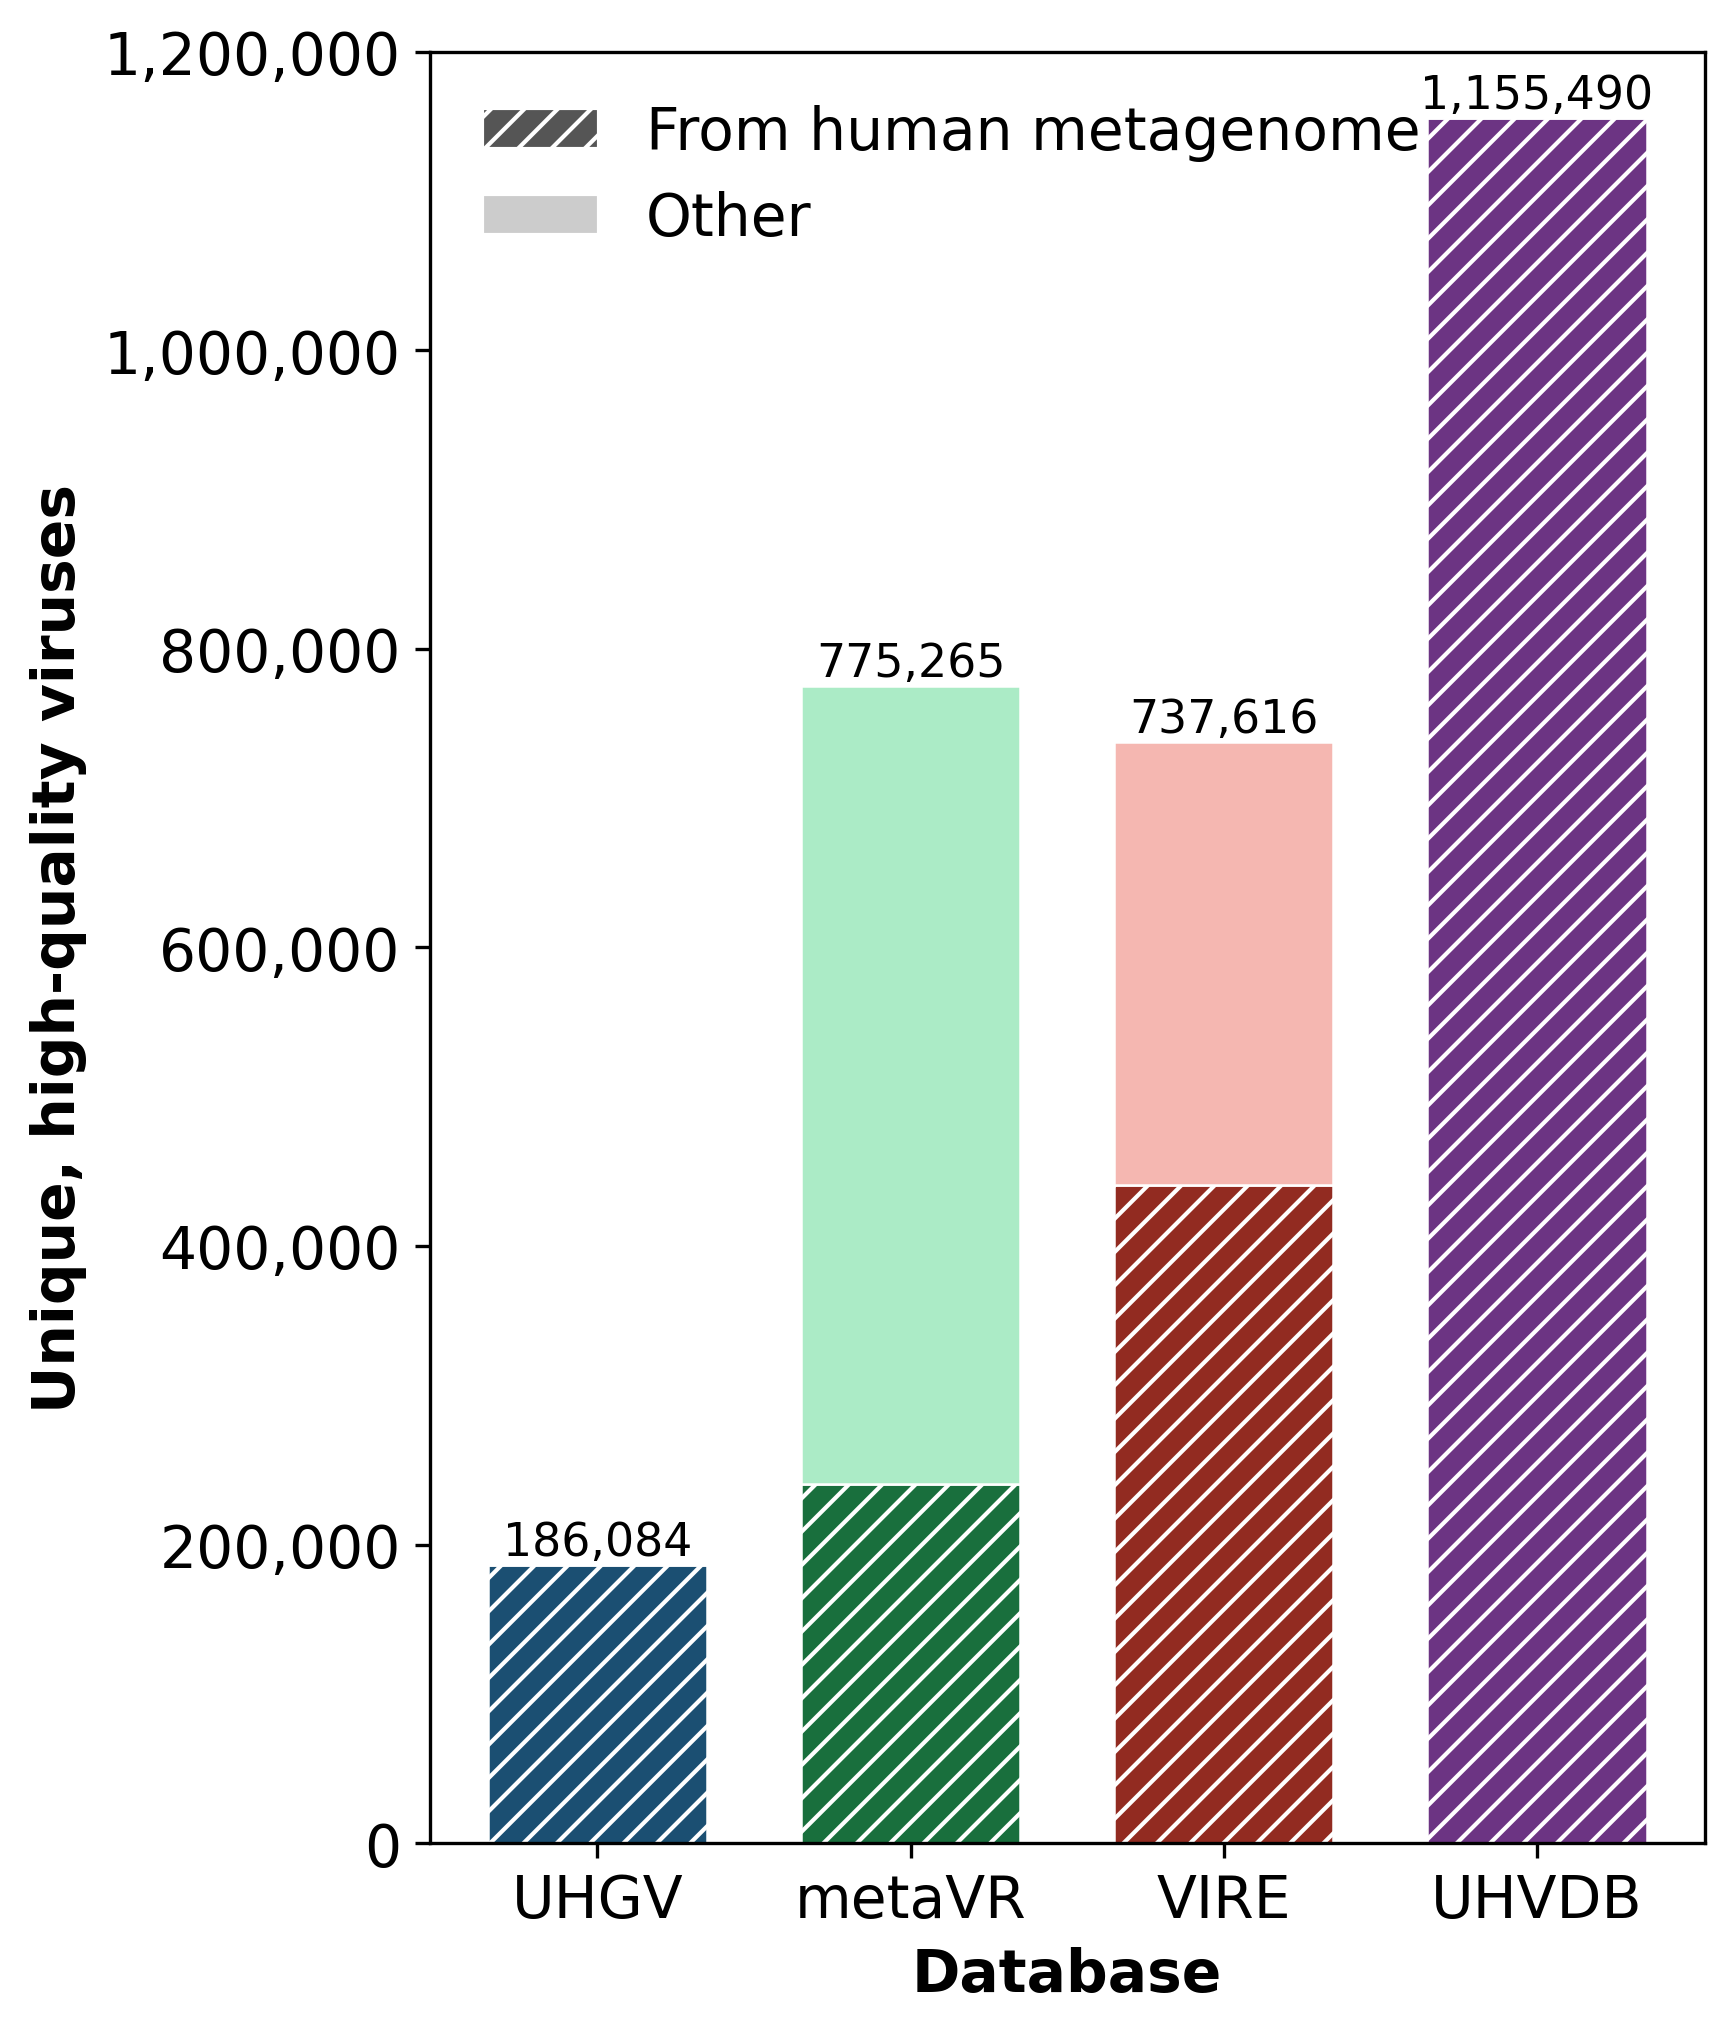

wrote /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript/figure_1/figure_1b_revision/plots/figure_1b_unique_hq_by_database.png


In [ ]:
import sys
from IPython.display import Image, display

if str(WORKDIR) not in sys.path:
    sys.path.insert(0, str(WORKDIR))
from count_and_plot_unißque_hq import plot_unique_hq_bars

out = plot_unique_hq_bars()  # reads data/unique_hq_hash_counts.tsv
display(Image(filename=out))
print("wrote", out)